In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv(
    "../data/raw/market_data.csv",
    header=[0,1],
    index_col=0
)

data.head()

Price           Close                                         High             \
Ticker           AAPL       MSFT         SPY       ^VIX       AAPL       MSFT   
Date                                                                            
2015-01-02  24.192606  39.681747  170.124985  17.790001  24.659508  40.241840   
2015-01-05  23.511057  39.316833  167.052628  19.920000  24.042131  39.656282   
2015-01-06  23.513275  38.739758  165.479095  21.120001  23.772173  39.673244   
2015-01-07  23.842979  39.231964  167.541229  19.309999  23.942555  39.427148   
2015-01-08  24.759083  40.386108  170.514267  17.010000  24.816616  40.521888   

Price                                    Low                         \
Ticker             SPY       ^VIX       AAPL       MSFT         SPY   
Date                                                                  
2015-01-02  171.325799  20.139999  23.754470  39.495052  169.089809   
2015-01-05  169.247196  21.290001  23.325182  39.248942  166.746219   
2015-01-06  167.880699  22.900000  23.152587  38.646408  164.684075   
2015-01-07  167.880770  20.719999  23.610634  38.603983  166.356994   
2015-01-08  170.729592  18.090000  24.053197  39.647805  168.932527   

Price                       Open                                       Volume  \
Ticker           ^VIX       AAPL       MSFT         SPY       ^VIX       AAPL   
Date                                                                            
2015-01-02  17.049999  24.648443  39.596886  170.911729  17.760000  212818400   
2015-01-05  19.190001  23.962469  39.350776  169.081571  19.190001  257142000   
2015-01-06  19.520000  23.575233  39.359254  167.358966  20.330000  263188400   
2015-01-07  19.040001  23.721274  39.019808  166.804184  20.150000  160423600   
2015-01-08  16.990000  24.170477  39.673262  168.949081  17.930000  237458000   

Price                                 
Ticker          MSFT        SPY ^VIX  
Date                                  
2015-01-02  27913900  121465900    0  
2015-01-05  39673900  169632600    0  
2015-01-06  36447900  209151400    0  
2015-01-07  29114100  125346700    0  
2015-01-08  29645200  147217800    0

In [2]:
close_prices = data["Close"]
close_prices.head()

Ticker,AAPL,MSFT,SPY,^VIX
Date,,,,
2015-01-02,24.192606,39.681747,170.124985,17.790001
2015-01-05,23.511057,39.316833,167.052628,19.920000
2015-01-06,23.513275,38.739758,165.479095,21.120001
2015-01-07,23.842979,39.231964,167.541229,19.309999
2015-01-08,24.759083,40.386108,170.514267,17.010000


In [3]:
returns = np.log(close_prices / close_prices.shift(1))
returns = returns.dropna()
returns.head()

Ticker,AAPL,MSFT,SPY,^VIX
Date,,,,
2015-01-05,-0.028576,-0.009239,-0.018224,0.113088
2015-01-06,0.000094,-0.014786,-0.009464,0.058496
2015-01-07,0.013925,0.012625,0.012385,-0.089597
2015-01-08,0.037703,0.028994,0.017590,-0.126822
2015-01-09,0.001072,-0.008441,-0.008046,0.031252


In [4]:
returns.to_csv("../data/processed/returns.csv")

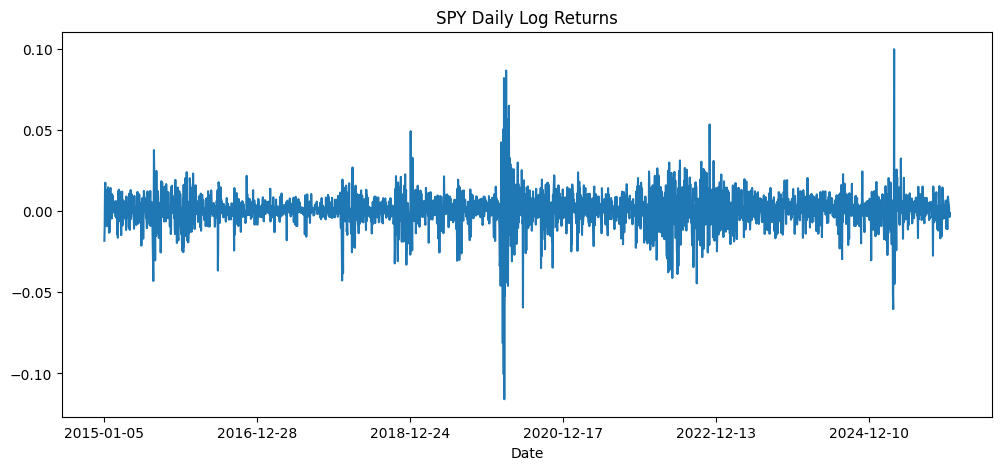

In [5]:
returns["SPY"].plot(
    figsize=(12,5),
    title="SPY Daily Log Returns"
)

plt.show()

In [6]:
vol_5 = returns.rolling(5).std()
vol_20 = returns.rolling(20).std()
vol_60 = returns.rolling(60).std()

In [7]:
features = pd.DataFrame()

features["SPY_return"] = returns["SPY"]

features["SPY_vol_5"] = vol_5["SPY"]
features["SPY_vol_20"] = vol_20["SPY"]
features["SPY_vol_60"] = vol_60["SPY"]

features = features.dropna()

In [8]:
features.to_csv(
    "../data/processed/volatility_features.csv"
)

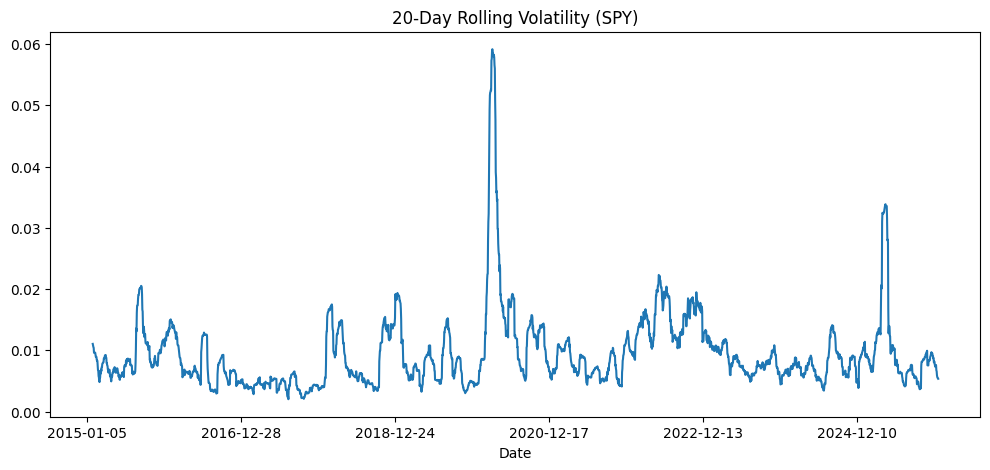

In [9]:
vol_20["SPY"].plot(
    figsize=(12,5),
    title="20-Day Rolling Volatility (SPY)"
)

plt.show()